# Test with a real data

In [1]:
import xarray as xr
import glob

from pcmdi_metrics.effective_resolution import compute_effective_resolution
import matplotlib.pyplot as plt
import numpy as np

## Prepare input

In [2]:
#datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/ECMWF-IFS-LR/hist-1950/6hrPlevPt"
#datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"
#datadir = "/home/lee1043/work/DATA/HighResMIP/ECMWF-IFS-LR/hist-1950/6hrPlevPt"
#datadir = "/home/lee1043/work/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"
#datadir = "/Users/lee1043/Documents/Research/DATA/HighResMIP/ECMWF-IFS-LR/highresSST-present/6hrPlevPt"
datadir = "/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt"

In [3]:
data_list = sorted(glob.glob(f"{datadir}/*/*CMCC-CM2-VHR4*_2014*.nc"))
data_list

['/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140101000000-20140131180000.nc',
 '/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140201000000-20140228180000.nc',
 '/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140301000000-20140331180000.nc',
 '/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140401000000-20140430180000.nc',
 '/global/cfs/cdirs/m4581/lee1043/DATA/CMIP6/HighResMIP/CMCC-CM2-VHR4/highresSST-present/6hrPlevPt/ua/ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140501000000-20140531180000.nc',
 '/global/cfs/cdirs/m4581

In [4]:
target_months = ('201403', '201406', '201409', '201412')

data_list = [
    data_path
    for data_path in data_list
    if any(month in data_path for month in target_months)
]

In [5]:
[filepath.split('/')[-1] for filepath in data_list]

['ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140301000000-20140331180000.nc',
 'ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140601000000-20140630180000.nc',
 'ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140901000000-20140930180000.nc',
 'ua_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20141201000000-20141231180000.nc',
 'va_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140301000000-20140331180000.nc',
 'va_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140601000000-20140630180000.nc',
 'va_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20140901000000-20140930180000.nc',
 'va_6hrPlevPt_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_20141201000000-20141231180000.nc']

In [6]:
ds = xr.open_mfdataset(data_list)

/tmp/ipykernel_212009/1960847013.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_list)
/tmp/ipykernel_212009/1960847013.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_list)
/tmp/ipykernel_212009/1960847013.py:1: FutureWarning: In a future version 

In [7]:
ds

<xarray.Dataset> Size: 24GB
Dimensions:    (time: 488, bnds: 2, lat: 768, lon: 1152, plev: 7)
Coordinates:
  * time       (time) object 4kB 2014-03-01 00:00:00 ... 2014-12-31 18:00:00
  * lat        (lat) float64 6kB -90.0 -89.77 -89.53 -89.3 ... 89.53 89.77 90.0
  * lon        (lon) float64 9kB 0.0 0.3125 0.625 0.9375 ... 359.1 359.4 359.7
  * plev       (plev) float64 56B 9.25e+04 8.5e+04 7e+04 ... 5e+04 2.5e+04 5e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 6MB dask.array<chunksize=(124, 768, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 9MB dask.array<chunksize=(124, 1152, 2), meta=np.ndarray>
    ua         (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 3, 384, 576), meta=np.ndarray>
    va         (time, plev, lat, lon) float32 12GB dask.array<chunksize=(1, 3, 384, 576), meta=np.ndarray>
Attributes: (12/42)
    Conventions:             CF-1.7 CMIP-6.0
    activity_id:             HighResMIP
    creation_date:           2017-11-07T07:40:37Z
    end_year:                2014
    experiment:              forced atmosphere experiment for 1950-2014
    experiment_id:           highresSST-present
    ...                      ...
    variant_label:           r1i1p1f1
    license:                 CMIP6 model data produced by CMCC is licensed un...
    cmor_version:            3.2.4
    further_info_url:        https://furtherinfo.es-doc.org/CMIP6.CMCC.CMCC-C...
    data_specs_version:      01.00.23
    history:                 2017-11-07T07:40:37Z CMOR rewrote data to be con...

## Metrics calculation

Takes ~2 min

In [8]:
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="CMCC-CM2-VHR4",
    member="r1i1p1f1",
    save_interim_netcdf=False,
)

result = metrics["CMCC-CM2-VHR4"]["r1i1p1f1"]
result

CPU times: user 1h 9min 59s, sys: 2min 24s, total: 1h 12min 24s
Wall time: 1h 13min 16s


{'effective_wavenumber': 146.0,
 'effective_resolution_km': 136.62254859044694,
 'grid_box_distance_km': 38.227725655503775,
 'resolution_ratio': 3.5739125529372666,
 'resolution_ratio_dx_convention': 10.108551206198669,
 'is_upper_limit': False,
 'n_spectra_steepening': 3,
 'steepening_wavenumber': {'div_250': 80.0,
  'rot_250': 146.0,
  'rot_500': 156.0},
 'steepening_eddy_scale_km': {'div_250': 248.63941473033594,
  'rot_250': 136.62254859044694,
  'rot_500': 127.89258113038436},
 'steepening_wavenumber_range': [80.0, 156.0],
 'criterion': {'fit_window': 20,
  'fit_anchor': 'right',
  'steepening_factor': 0.25,
  'wavenumber_ratio': 2.0,
  'min_wavenumber': 32,
  'n_confirm': 2},
 'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}

Save interim fime for cross validation (takes longer time ~8 min)

In [9]:
"""
%%time

metrics, diagnostics = compute_effective_resolution(
    ds,
    uvar="ua",
    vvar="va",
    levels=(250.0, 500.0),
    model="ECMWF-IFS-LR",
    member="r1i1p1f1",
    save_interim_netcdf=True,
)

result = metrics["ECMWF-IFS-LR"]["r1i1p1f1"]
result
"""

'\n%%time\n\nmetrics, diagnostics = compute_effective_resolution(\n    ds,\n    uvar="ua",\n    vvar="va",\n    levels=(250.0, 500.0),\n    model="ECMWF-IFS-LR",\n    member="r1i1p1f1",\n    save_interim_netcdf=True,\n)\n\nresult = metrics["ECMWF-IFS-LR"]["r1i1p1f1"]\nresult\n'

## Analysis (temporary interim data)

## Analysis (diagnostics)

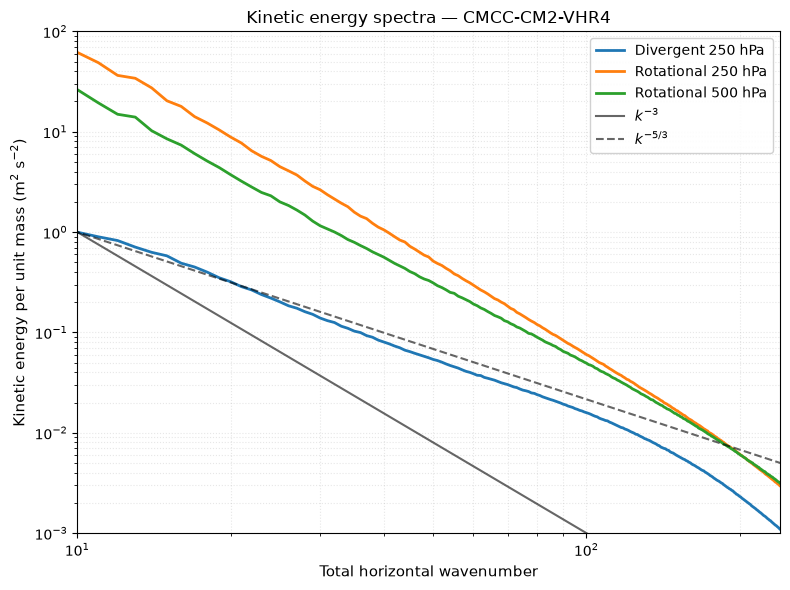

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the kinetic energy spectra
spectra = diagnostics["spectra"]
colors = {"div": "C0", "rot_250": "C1", "rot_500": "C2"}
labels = {"div": "Divergent 250 hPa", "rot_250": "Rotational 250 hPa", 
          "rot_500": "Rotational 500 hPa"}

# Plot divergent at 250 hPa
spec_250 = spectra[250.0]
wavenumber = spec_250["wavenumber"].values
ke_div = spec_250["ke_div"].values
ax.loglog(wavenumber, ke_div, color=colors["div"], linewidth=2, label=labels["div"])

# Plot rotational at 250 hPa
ke_rot_250 = spec_250["ke_rot"].values
ax.loglog(wavenumber, ke_rot_250, color=colors["rot_250"], linewidth=2, label=labels["rot_250"])

# Plot rotational at 500 hPa
spec_500 = spectra[500.0]
ke_rot_500 = spec_500["ke_rot"].values
ax.loglog(wavenumber, ke_rot_500, color=colors["rot_500"], linewidth=2, label=labels["rot_500"])

# Add reference lines for k^-3 and k^-5/3
# Control where reference lines start by specifying y-value at a reference wavenumber
k_ref_start = 10.0       # Reference wavenumber where we set the y-value
y_ref_value = 1e0        # Y-axis value at k_ref_start for both reference lines

k_ref = np.logspace(0, 3, 100)  # wavenumbers from 1 to 1000

# Calculate amplitude to make reference line pass through (k_ref_start, y_ref_value)
# For k^-3: y = A * k^-3, so A = y * k^3
amplitude_k3 = y_ref_value * k_ref_start**3
amplitude_k53 = y_ref_value * k_ref_start**(5/3)

ke_ref_k3 = amplitude_k3 * k_ref**(-3)
ke_ref_k53 = amplitude_k53 * k_ref**(-5/3)

ax.loglog(k_ref, ke_ref_k3, 'k-', linewidth=1.5, alpha=0.6, label=r'$k^{-3}$')
ax.loglog(k_ref, ke_ref_k53, 'k--', linewidth=1.5, alpha=0.6, label=r'$k^{-5/3}$')

ax.set_xlim(10, 240)
ax.set_ylim(1e-3, 1e2)
ax.set_xlabel("Total horizontal wavenumber", fontsize=11)
ax.set_ylabel(r"Kinetic energy per unit mass (m$^2$ s$^{-2}$)", fontsize=11)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3, linestyle=":")
ax.set_title("Kinetic energy spectra — CMCC-CM2-VHR4", fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
metrics

{'CMCC-CM2-VHR4': {'r1i1p1f1': {'effective_wavenumber': 146.0,
   'effective_resolution_km': 136.62254859044694,
   'grid_box_distance_km': 38.227725655503775,
   'resolution_ratio': 3.5739125529372666,
   'resolution_ratio_dx_convention': 10.108551206198669,
   'is_upper_limit': False,
   'n_spectra_steepening': 3,
   'steepening_wavenumber': {'div_250': 80.0,
    'rot_250': 146.0,
    'rot_500': 156.0},
   'steepening_eddy_scale_km': {'div_250': 248.63941473033594,
    'rot_250': 136.62254859044694,
    'rot_500': 127.89258113038436},
   'steepening_wavenumber_range': [80.0, 156.0],
   'criterion': {'fit_window': 20,
    'fit_anchor': 'right',
    'steepening_factor': 0.25,
    'wavenumber_ratio': 2.0,
    'min_wavenumber': 32,
    'n_confirm': 2},
   'reference': 'Klaver et al. (2020), doi:10.1002/asl.952'}}}

### Compensated vs. Uncompensated Spectra

The `plot_spectra_and_slope` function supports both:

1. **Compensated spectra** (default, `compensate=3.0`): Reproduces Figure 1 from Klaver et al. (2020)
   - Y-axis shows $l^3 E_l$, making a $k^{-3}$ spectrum appear flat
   - Highlights deviations from the reference power laws
   - Easier to see spectral steepening

2. **Uncompensated spectra** (`compensate=None` or `compensate=0`): Reproduces Figure S3 from supplementary material
   - Y-axis shows raw spectrum in m²/s²
   - Power-law slopes appear as straight lines in log-log space
   - Shows the full dynamic range of the spectra

Both styles show the same data but emphasize different aspects of the spectral behavior.

In [12]:
from pcmdi_metrics.effective_resolution.lib import (
    plot_spectra_and_slope,
)

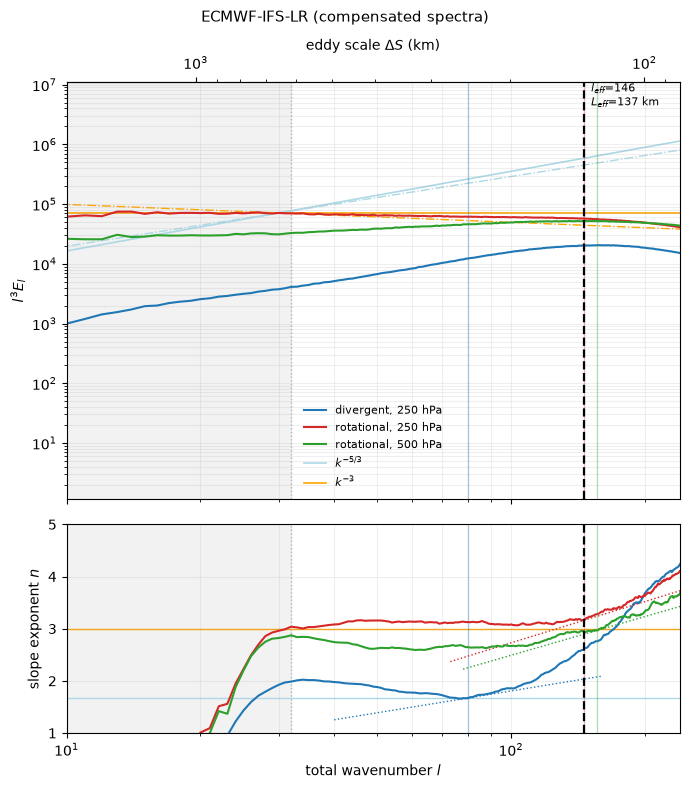

In [13]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    #compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    #spec_ylim=(1e-2, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="ECMWF-IFS-LR (compensated spectra)"
)
plt.show()

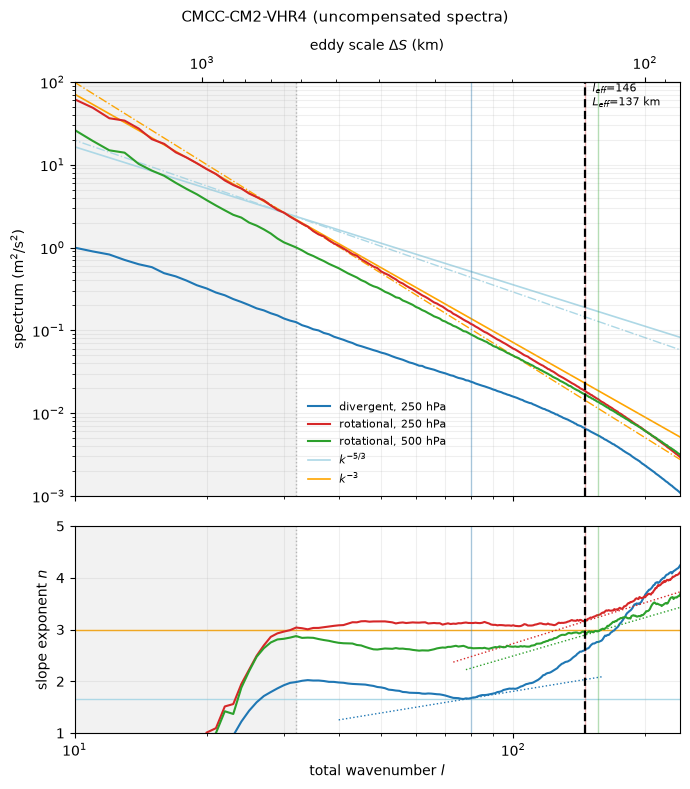

In [14]:
# Test uncompensated spectra (Figure S3 style)
# Set compensate=None or compensate=0 to plot without l^-3 compensation
fig = plot_spectra_and_slope(
    diagnostics, 
    result,
    compensate=None,         # Turn OFF compensation (Figure S3)
    xlim=(10, 240),          # Wavenumber range
    spec_ylim=(1e-3, 1e2),   # Uncompensated spectrum y-range
    slope_ylim=(1, 5),       # Slope panel y-range
    title="CMCC-CM2-VHR4 (uncompensated spectra)"
)
plt.show()

## Figure 2 — Effective vs. Nominal Resolution Scatter Plot

This reproduces Figure 2 from Klaver et al. (2020), showing the relationship between effective resolution (L_eff) and grid box distance (L_box). The ratio L_eff/L_box is color-coded and ranges from 2.7 to 4.8 across the HighResMIP models in the paper.

**Note**: This example shows only one configuration (ECMWF-IFS-LR regridded to 1°). The scatter plot is most useful when comparing multiple models or resolution configurations of the same model (e.g., LR vs HR versions).

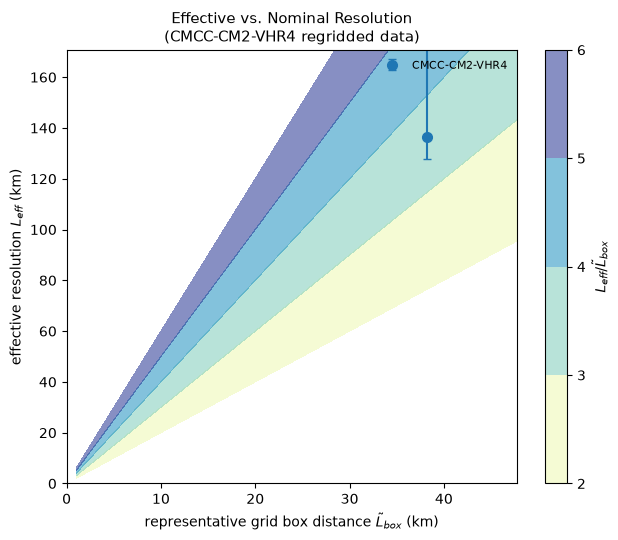


Note: This data point shows:
  - Grid box distance: 38.2 km
  - Effective resolution: 136.62254859044694 (if None: insufficient steepening)
  - Only 1 of 3 spectra steepened (need 2+ for confirmation)

From Klaver et al. Table 1, native CMCC-CM2-VHR4should have:
  - Grid box distance: 38.2 km
  - Effective wavenumber: l=110
  - Effective resolution: 192 km
  - Ratio: 4.8


In [ ]:
from pcmdi_metrics.effective_resolution.lib import plot_resolution_scatter

# For this example, we only have one model configuration
# In practice, you would have multiple models or configurations to compare
ensemble = [result]
labels = ["CMCC-CM2-VHR4"]

# Note: The plot shows this is regridded data (not native grid)
# The effective resolution couldn't be determined (None) because only 1 spectrum steepened
# For proper analysis, use native grid data (gn) instead of regridded (gr)

fig = plot_resolution_scatter(
    ensemble, 
    labels=labels, 
    title="Effective vs. Nominal Resolution\n(CMCC-CM2-VHR4 regridded data)"
)
plt.show()

print("\nNote: This data point shows:")
print(f"  - Grid box distance: {result['grid_box_distance_km']:.1f} km")
print(f"  - Effective resolution: {result['effective_resolution_km']} (if None: insufficient steepening)")
print(f"  - Only 1 of 3 spectra steepened (need 2+ for confirmation)")
print("\nFrom Klaver et al. Table 1, native CMCC-CM2-VHR4 should have:")
print("  - Grid box distance: 38.2 km")
print("  - Effective wavenumber: l=110")
print("  - Effective resolution: 192 km")
print("  - Ratio: 4.8")